# Music Predictive Analytics Project

This notebook analyzes the music dataset and the real user interaction files created by the Streamlit app.

Shared backend files:
- `top10s.csv`
- `users.csv`
- `user_preferences.csv`
- `listening_history.csv`
- `ratings.csv`
- `recommendation_logs.csv`


In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import os
from datetime import datetime
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

In [2]:

# ============================================================
# 2. FILE PATHS AND COLUMN DEFINITIONS
# ============================================================
SONG_FILE = "top10s.csv"
USERS_FILE = "users.csv"
USER_PREF_FILE = "user_preferences.csv"
HISTORY_FILE = "listening_history.csv"
RATINGS_FILE = "ratings.csv"
RECOMMENDATION_LOG_FILE = "recommendation_logs.csv"

TRACK_COL = "title"
ARTIST_COL = "artist"
GENRE_COL = "top_genre"
POPULARITY_COL = "pop"

NUMERIC_FEATURES = [
    "year", "bpm", "nrgy", "dnce", "db", "live",
    "val", "dur", "acous", "spch"
]


In [3]:
# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================
def clean_text_regex(value):
    """Clean text using regex so duplicate song/artist names match more consistently."""
    if pd.isna(value):
        return value
    value = str(value).lower().strip()
    value = value.replace("&", "and")
    value = pd.Series([value]).str.replace(r"[^a-z0-9\s]", "", regex=True).iloc[0]
    value = pd.Series([value]).str.replace(r"\s+", " ", regex=True).iloc[0]
    return value.strip()

def normalize_song_columns(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    if "unnamed:_0" in df.columns:
        df = df.drop(columns=["unnamed:_0"])

    # Regex-based duplicate cleaning keys
    if TRACK_COL in df.columns:
        df["title_clean"] = df[TRACK_COL].apply(clean_text_regex)
    if ARTIST_COL in df.columns:
        df["artist_clean"] = df[ARTIST_COL].apply(clean_text_regex)

    before = len(df)
    df = df.drop_duplicates()

    if "title_clean" in df.columns and "artist_clean" in df.columns:
        df = df.drop_duplicates(subset=["title_clean", "artist_clean"])

    after = len(df)
    print(f"Duplicate rows removed using regex-cleaned title/artist keys: {before - after}")
    return df

def read_csv_if_exists(path, columns):
    if os.path.exists(path):
        return pd.read_csv(path)
    return pd.DataFrame(columns=columns)

def split_genres(value):
    if pd.isna(value) or str(value).strip() == "":
        return []
    return [g.strip() for g in str(value).split(";") if g.strip()]

def get_time_feature_score(row, time_period):
    bpm_scaled = min(float(row.get("bpm", 0)) / 200, 1) * 100

    if time_period == "Morning":
        score = (
            0.30 * row.get("acous", 0) +
            0.25 * (100 - row.get("nrgy", 0)) +
            0.25 * row.get("val", 0) +
            0.20 * row.get("dnce", 0)
        )
    elif time_period == "Afternoon":
        score = (
            0.30 * row.get("dnce", 0) +
            0.25 * row.get("nrgy", 0) +
            0.20 * row.get("val", 0) +
            0.15 * bpm_scaled +
            0.10 * (100 - row.get("acous", 0))
        )
    elif time_period == "Evening":
        score = (
            0.35 * row.get("acous", 0) +
            0.25 * (100 - row.get("nrgy", 0)) +
            0.20 * row.get("val", 0) +
            0.20 * (100 - bpm_scaled)
        )
    else:
        score = (
            0.35 * row.get("nrgy", 0) +
            0.30 * row.get("dnce", 0) +
            0.20 * bpm_scaled +
            0.15 * row.get("val", 0)
        )

    return max(0, min(100, score)) / 100


In [4]:

# ============================================================
# 4. LOAD SONG DATA AND REAL USER BACKEND FILES
# ============================================================
songs_df = pd.read_csv(SONG_FILE, encoding="latin1")
songs_df = normalize_song_columns(songs_df)

numeric_features = [c for c in NUMERIC_FEATURES if c in songs_df.columns]

for col in numeric_features + [POPULARITY_COL]:
    songs_df[col] = pd.to_numeric(songs_df[col], errors="coerce")

users_df = read_csv_if_exists(USERS_FILE, ["user_id", "username", "email", "created_at"])
user_pref_df = read_csv_if_exists(USER_PREF_FILE, ["user_id", "preferred_genres", "created_at", "updated_at"])
history_df = read_csv_if_exists(HISTORY_FILE, ["history_id", "user_id", "title", "artist", "top_genre", "time_period", "mood", "listened_at"])
ratings_df = read_csv_if_exists(RATINGS_FILE, ["rating_id", "user_id", "title", "artist", "top_genre", "rating", "liked", "time_period", "rated_at"])
recommendation_logs_df = read_csv_if_exists(RECOMMENDATION_LOG_FILE, ["log_id", "user_id", "title", "artist", "top_genre", "time_period", "final_score", "reason", "recommended_at"])

print("Songs:", songs_df.shape)
print("Users:", users_df.shape)
print("User preferences:", user_pref_df.shape)
print("Listening history:", history_df.shape)
print("Ratings:", ratings_df.shape)
print("Recommendation logs:", recommendation_logs_df.shape)

songs_df.head()


Duplicate rows removed using regex-cleaned title/artist keys: 16
Songs: (587, 16)
Users: (51, 4)
User preferences: (51, 4)
Listening history: (1253, 9)
Ratings: (819, 10)
Recommendation logs: (188, 9)


,title,artist,top_genre,year,bpm,nrgy,dnce,db,live,val,dur,acous,spch,pop,title_clean,artist_clean
0,"Hey, Soul Sister",Train,neo mellow,2010,97,89,67,-4,8,80,217,19,4,83,hey soul sister,train
1,Love The Way You Lie,Eminem,detroit hip hop,2010,87,93,75,-5,52,64,263,24,23,82,love the way you lie,eminem
2,TiK ToK,Kesha,dance pop,2010,120,84,76,-3,29,71,200,10,14,80,tik tok,kesha
3,Bad Romance,Lady Gaga,dance pop,2010,119,92,70,-4,8,71,295,0,4,79,bad romance,lady gaga
4,Just the Way You Are,Bruno Mars,pop,2010,109,84,64,-5,9,43,221,2,4,78,just the way you are,bruno mars


## Fixes Added Before Modeling

The following cells add the missing parts: realistic fake user behavior, regex duplicate cleaning, outlier detection, scaling, tuning, class imbalance handling, and real liked-label preference prediction.


In [5]:
# ============================================================
# 4B. USERS + PREFERENCES + HISTORY + RATINGS
# ============================================================

import random

GENERATE_FAKE_REALISTIC_USERS = False
N_USERS = 50
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Make sure every song has a stable song_id for joining user behavior to songs
if "song_id" not in songs_df.columns:
    songs_df = songs_df.reset_index(drop=True)
    songs_df["song_id"] = songs_df.index + 1

if GENERATE_FAKE_REALISTIC_USERS:
    first_names = [
        "Shreya","Alex","Maya","Noah","Sara","Daniel","Priya","Ethan","Aarav","Emma",
        "Liam","Olivia","Arjun","Aisha","Kabir","Neha","Rohan","Isha","Karan","Ananya",
        "Vikram","Nina","Rahul","Meera","Aditya","Riya","Dev","Sanya","Aman","Pooja",
        "Kunal","Sneha","Rakesh","Tanya","Varun","Ishaan","Zara","Yash","Ankit","Diya",
        "Manish","Swati","Harsh","Kavya","Ritu","Ravi","Nikhil","Simran","Arnav","Payal"
    ]

    last_names = [
        "Mondal","Johnson","Patel","Smith","Khan","Lee","Sharma","Wilson","Brown","Davis",
        "Miller","Anderson","Thomas","Jackson","White","Harris","Martin","Thompson","Garcia","Martinez",
        "Robinson","Clark","Rodriguez","Lewis","Walker","Hall","Allen","Young","King","Wright",
        "Scott","Green","Baker","Adams","Nelson","Hill","Ramirez","Campbell","Mitchell","Roberts",
        "Carter","Phillips","Evans","Turner","Torres","Parker","Collins","Edwards","Stewart","Morris"
    ]

    domains = ["gmail.com", "yahoo.com", "outlook.com", "hotmail.com"]
    time_periods = ["Morning", "Afternoon", "Evening", "Night"]

    def make_email(first, last):
        pattern = random.choice([
            f"{first.lower()}.{last.lower()}",
            f"{first.lower()}{last.lower()}",
            f"{first[0].lower()}{last.lower()}",
            f"{first.lower()}{random.randint(10,99)}",
        ])
        return f"{pattern}@{random.choice(domains)}"

    users = []
    used_usernames = set()
    used_emails = set()

    for user_id in range(1, N_USERS + 1):
        first = first_names[user_id - 1]
        last = last_names[user_id - 1]

        username = first
        suffix = 1
        while username.lower() in used_usernames:
            suffix += 1
            username = f"{first}{suffix}"
        used_usernames.add(username.lower())

        email = make_email(first, last)
        while email.lower() in used_emails:
            email = make_email(first, last)
        used_emails.add(email.lower())

        users.append({
            "user_id": user_id,
            "username": username,
            "email": email,
            "created_at": datetime.now() - pd.Timedelta(days=random.randint(1, 60))
        })

    users_df = pd.DataFrame(users)

    # Each user gets 2-4 favorite genres
    available_genres = songs_df[GENRE_COL].dropna().unique().tolist()
    user_pref_rows = []
    for user_id in users_df["user_id"]:
        k = min(random.randint(2, 4), len(available_genres))
        prefs = random.sample(available_genres, k=k)
        user_pref_rows.append({
            "user_id": user_id,
            "preferred_genres": ";".join(prefs),
            "created_at": datetime.now() - pd.Timedelta(days=random.randint(1, 60))
        })
    user_pref_df = pd.DataFrame(user_pref_rows)

    # Generate listening history and ratings from each user's genre preferences
    history_rows = []
    rating_rows = []

    for _, user in users_df.iterrows():
        user_id = int(user["user_id"])
        preferred_genres = split_genres(user_pref_df.loc[user_pref_df["user_id"] == user_id, "preferred_genres"].iloc[0])

        preferred_pool = songs_df[songs_df[GENRE_COL].isin(preferred_genres)]
        other_pool = songs_df[~songs_df[GENRE_COL].isin(preferred_genres)]

        # 25 listening records per user, mostly from preferred genres
        for _ in range(25):
            pool = preferred_pool if random.random() < 0.75 and not preferred_pool.empty else other_pool
            song = pool.sample(1, random_state=random.randint(1, 999999)).iloc[0]
            time_period = random.choice(time_periods)

            history_rows.append({
                "user_id": user_id,
                "song_id": int(song["song_id"]),
                TRACK_COL: song[TRACK_COL],
                ARTIST_COL: song[ARTIST_COL],
                GENRE_COL: song[GENRE_COL],
                "time_period": time_period,
                "listened_at": datetime.now() - pd.Timedelta(days=random.randint(0, 60), hours=random.randint(0, 23))
            })

            # 65% of listened songs receive a rating
            if random.random() < 0.65:
                genre_match = song[GENRE_COL] in preferred_genres
                pop_score = float(song[POPULARITY_COL]) if pd.notna(song[POPULARITY_COL]) else songs_df[POPULARITY_COL].median()

                # More realistic rating: preferred genre + popularity + small randomness
                base = 3.0
                base += 0.9 if genre_match else -0.4
                base += (pop_score - songs_df[POPULARITY_COL].median()) / 35
                base += np.random.normal(0, 0.75)

                rating = int(np.clip(round(base), 1, 5))
                liked = 1 if rating >= 4 else 0

                rating_rows.append({
                    "user_id": user_id,
                    "song_id": int(song["song_id"]),
                    TRACK_COL: song[TRACK_COL],
                    ARTIST_COL: song[ARTIST_COL],
                    GENRE_COL: song[GENRE_COL],
                    "time_period": time_period,
                    "rating": rating,
                    "liked": liked,
                    "rated_at": datetime.now() - pd.Timedelta(days=random.randint(0, 60), hours=random.randint(0, 23))
                })

    history_df = pd.DataFrame(history_rows)
    ratings_df = pd.DataFrame(rating_rows)

    users_df.to_csv(USERS_FILE, index=False)
    user_pref_df.to_csv(USER_PREF_FILE, index=False)
    history_df.to_csv(HISTORY_FILE, index=False)
    ratings_df.to_csv(RATINGS_FILE, index=False)

    print("Fake realistic backend data generated and saved.")
    print("Users:", len(users_df))
    print("Listening records:", len(history_df))
    print("Ratings:", len(ratings_df))
    print("Liked distribution:")
    display(ratings_df["liked"].value_counts(normalize=True).rename("percentage") * 100)
    display(users_df.head())
    display(user_pref_df.head())
    display(history_df.head())
    display(ratings_df.head())


### Dataset EDA

In [6]:
# ==============================
# FIX TIME COLUMN ISSUE
# ==============================

# Standardize column name to 'time_period'

if "time_of_day" in history_df.columns and "time_period" not in history_df.columns:
    history_df["time_period"] = history_df["time_of_day"]

if "time_of_day" in ratings_df.columns and "time_period" not in ratings_df.columns:
    ratings_df["time_period"] = ratings_df["time_of_day"]

# If ratings doesn't have any time info
if "time_period" not in ratings_df.columns:
    ratings_df["time_period"] = "Unknown"

print("History columns:", history_df.columns.tolist())
print("Ratings columns:", ratings_df.columns.tolist())

History columns: ['history_id', 'user_id', 'title', 'artist', 'top_genre', 'time_period', 'mood', 'listened_at', 'song_id']
Ratings columns: ['rating_id', 'user_id', 'title', 'artist', 'top_genre', 'rating', 'liked', 'time_period', 'rated_at', 'song_id']


In [7]:
# ============================================================
# SHOW USER LISTENING + RATINGS TABLE
# ============================================================

user_song_activity_df = ratings_df.merge(
    users_df[["user_id", "username", "email"]],
    on="user_id",
    how="left"
)

cols_to_show = [
    "user_id",
    "username",
    "email",
    "title",
    "artist",
    "top_genre",
    "rating",
    "liked",
    "time_period",
    "rated_at"
]

cols_to_show = [c for c in cols_to_show if c in user_song_activity_df.columns]

user_song_activity_df = user_song_activity_df[cols_to_show]

display(user_song_activity_df.head(20))

,user_id,username,email,title,artist,top_genre,rating,liked,time_period,rated_at
0,1,Shreya,shreya.mondal@gmail.com,True Colors,Zedd,complextro,4,1,Morning,2026-03-10 01:45:26.163366
1,1,Shreya,shreya.mondal@gmail.com,Treat You Better,Shawn Mendes,canadian pop,4,1,Morning,2026-03-30 03:45:26.165382
2,1,Shreya,shreya.mondal@gmail.com,Higher,Carly Rae Jepsen,canadian pop,4,1,Evening,2026-04-15 10:45:26.169413
3,1,Shreya,shreya.mondal@gmail.com,Stay,Zedd,complextro,5,1,Morning,2026-03-16 05:45:26.171164
4,1,Shreya,shreya.mondal@gmail.com,Stay The Night - Featuring Hayley Williams Of ...,Zedd,complextro,4,1,Morning,2026-04-28 17:45:26.172681
5,1,Shreya,shreya.mondal@gmail.com,Run Away With Me,Carly Rae Jepsen,canadian pop,4,1,Afternoon,2026-03-20 05:45:26.172681
6,1,Shreya,shreya.mondal@gmail.com,Cut To The Feeling,Carly Rae Jepsen,canadian pop,5,1,Morning,2026-03-20 02:45:26.177769
7,1,Shreya,shreya.mondal@gmail.com,Stay The Night - Featuring Hayley Williams Of ...,Zedd,complextro,4,1,Evening,2026-03-20 03:45:26.179507
8,1,Shreya,shreya.mondal@gmail.com,Get Low (with Liam Payne),Zedd,complextro,3,0,Afternoon,2026-03-27 15:45:26.179507
9,1,Shreya,shreya.mondal@gmail.com,Been You,Justin Bieber,canadian pop,4,1,Night,2026-04-11 01:45:26.179507


In [8]:

# ============================================================
# 5. BASIC DATASET CHECKS
# ============================================================
print("Columns:")
print(songs_df.columns.tolist())

print("\nMissing values:")
print(songs_df.isnull().sum())

print("\nDescriptive statistics:")
display(songs_df[numeric_features + [POPULARITY_COL]].describe())


Columns:
['title', 'artist', 'top_genre', 'year', 'bpm', 'nrgy', 'dnce', 'db', 'live', 'val', 'dur', 'acous', 'spch', 'pop', 'title_clean', 'artist_clean', 'song_id']

Missing values:
title           0
artist          0
top_genre       0
year            0
bpm             0
nrgy            0
dnce            0
db              0
live            0
val             0
dur             0
acous           0
spch            0
pop             0
title_clean     0
artist_clean    0
song_id         0
dtype: int64

Descriptive statistics:


,year,bpm,nrgy,dnce,db,live,val,dur,acous,spch,pop
count,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000
mean,2014.589438,118.659284,70.494037,64.480409,-5.568995,17.853492,52.226576,224.597956,14.233390,8.275980,66.425894
std,2.611361,24.860493,16.271729,13.384988,2.825395,13.155762,22.512752,34.151118,20.560534,7.303664,14.623928
min,2010.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,134.000000,0.000000,0.000000,0.000000
25%,2013.000000,100.000000,61.000000,57.000000,-6.000000,9.000000,35.000000,202.000000,2.000000,4.000000,60.000000
50%,2015.000000,120.000000,74.000000,66.000000,-5.000000,12.000000,52.000000,221.000000,6.000000,5.000000,69.000000
75%,2017.000000,129.000000,82.000000,73.000000,-4.000000,24.000000,69.000000,239.500000,17.000000,9.000000,76.000000
max,2019.000000,206.000000,98.000000,97.000000,-2.000000,74.000000,98.000000,424.000000,99.000000,48.000000,99.000000


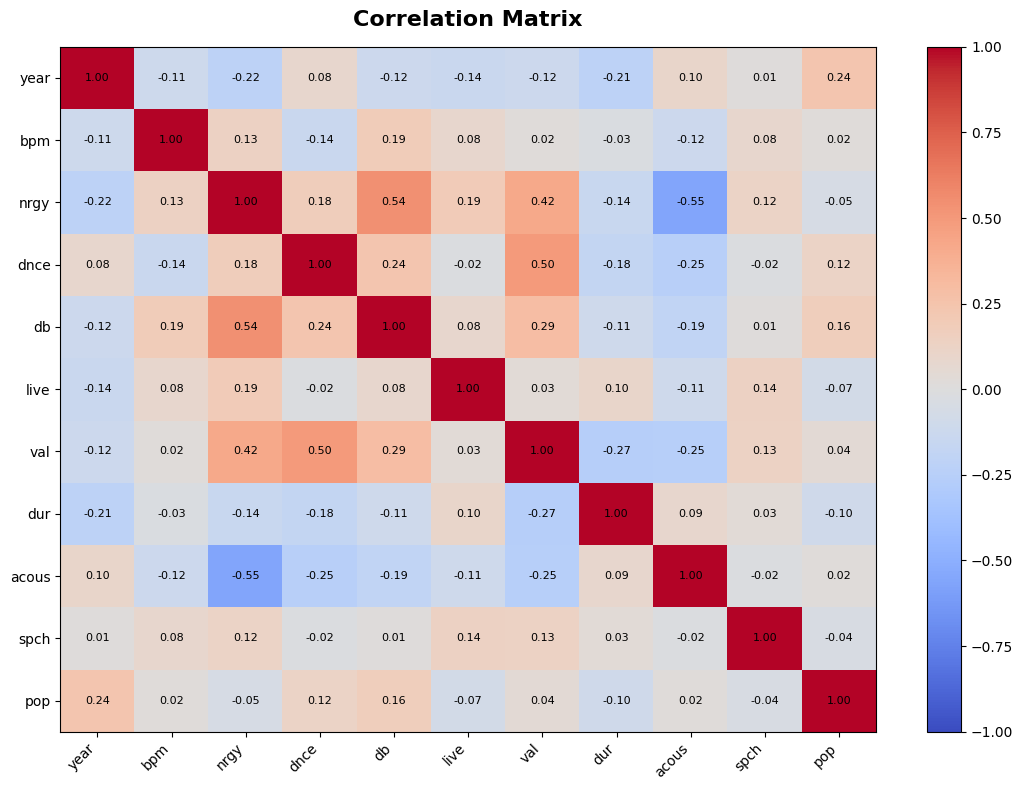

Correlation with popularity:


pop      1.000000
year     0.239412
db       0.164181
dnce     0.117833
val      0.043589
acous    0.019930
bpm      0.016044
spch    -0.041668
nrgy    -0.049752
live    -0.073269
dur     -0.099943
Name: pop, dtype: float64

In [32]:
# ============================================================
# 6. CORRELATION MATRIX
# ============================================================
corr_cols = numeric_features + [POPULARITY_COL]
corr_df = songs_df[corr_cols].corr()

plt.figure(figsize=(11, 8))

# Better color style
im = plt.imshow(
    corr_df,
    cmap="coolwarm",      # nice blue-red contrast
    vmin=-1,
    vmax=1,
    aspect="auto"
)

cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=10)

# Axis labels
plt.xticks(
    range(len(corr_df.columns)),
    corr_df.columns,
    rotation=45,
    ha="right",
    fontsize=10
)

plt.yticks(
    range(len(corr_df.columns)),
    corr_df.columns,
    fontsize=10
)

# Add correlation values inside cells
for i in range(len(corr_df.columns)):
    for j in range(len(corr_df.columns)):
        plt.text(
            j,
            i,
            f"{corr_df.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8
        )

plt.title(
    "Correlation Matrix",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

print("Correlation with popularity:")
display(corr_df[POPULARITY_COL].sort_values(ascending=False))

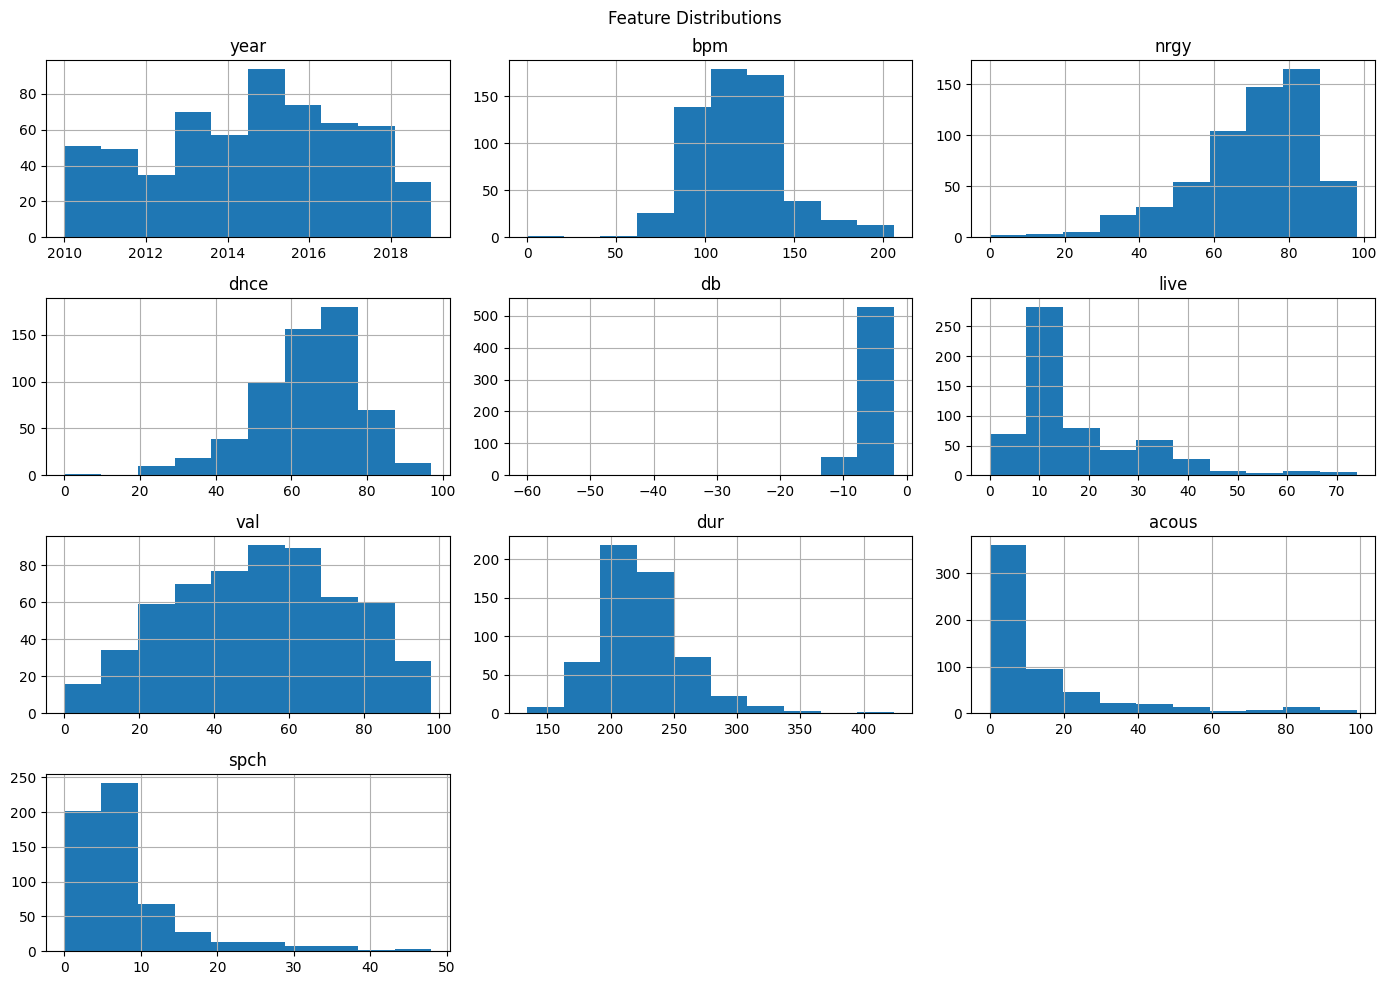

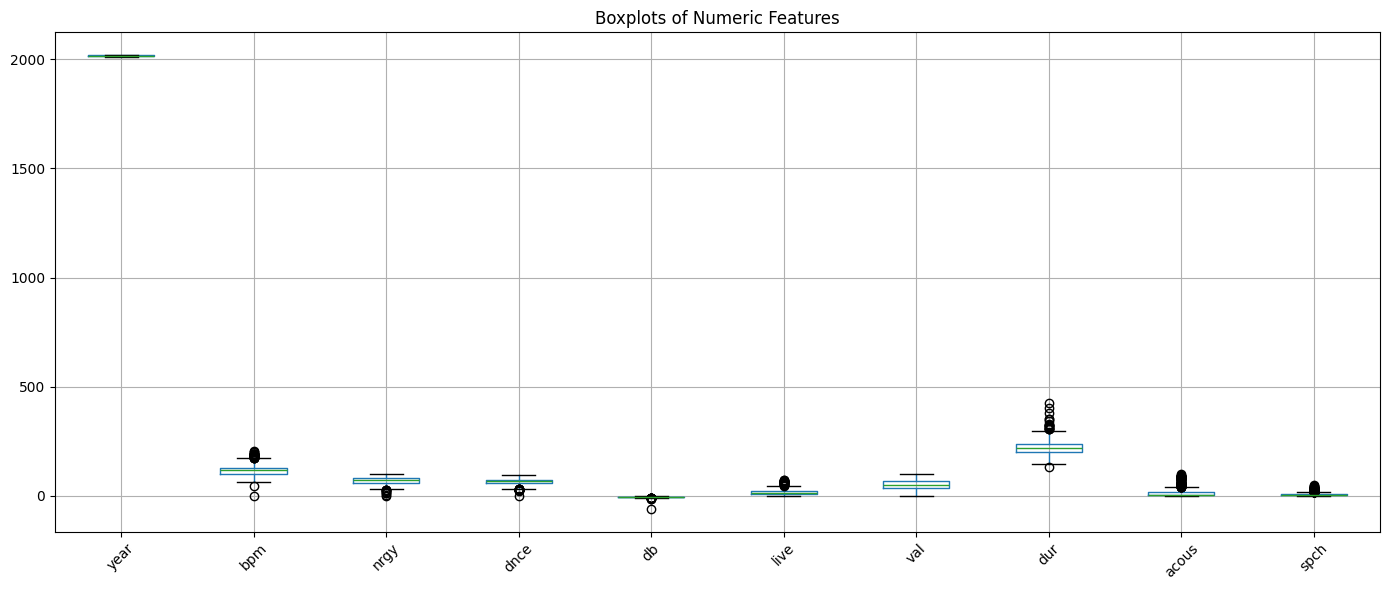

In [10]:

# ============================================================
# 7. FEATURE DISTRIBUTIONS AND BOXPLOTS
# ============================================================
songs_df[numeric_features].hist(figsize=(14, 10))
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
songs_df[numeric_features].boxplot(rot=45)
plt.title("Boxplots of Numeric Features")
plt.tight_layout()
plt.show()


In [11]:
# ============================================================
# 7B. OUTLIER IDENTIFICATION USING IQR
# ============================================================
outlier_summary = []

for col in numeric_features + [POPULARITY_COL]:
    q1 = songs_df[col].quantile(0.25)
    q3 = songs_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((songs_df[col] < lower) | (songs_df[col] > upper)).sum()

    outlier_summary.append({
        "feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(count)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("outlier_count", ascending=False)
display(outlier_df)


,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
8,acous,2.0,17.0,15.0,-20.50,39.50,64
9,spch,4.0,9.0,5.0,-3.50,16.50,63
1,bpm,100.0,129.0,29.0,56.50,172.50,28
5,live,9.0,24.0,15.0,-13.50,46.50,22
10,pop,60.0,76.0,16.0,36.00,100.00,21
7,dur,202.0,239.5,37.5,145.75,295.75,18
3,dnce,57.0,73.0,16.0,33.00,97.00,16
4,db,-6.0,-4.0,2.0,-9.00,-1.00,14
2,nrgy,61.0,82.0,21.0,29.50,113.50,10
0,year,2013.0,2017.0,4.0,2007.00,2023.00,0


## Predictive Modeling: Popularity Prediction

In [12]:
# ============================================================
# 8. REGRESSION MODELS: POPULARITY PREDICTION
# Improvements included here:
# 1. Uses all available Spotify audio features from numeric_features
# 2. Adds Decision Tree Regressor and tuned Random Forest Regressor
# 3. Adds log-transformed Random Forest to test whether RMSE improves
# 4. Keeps Linear and Polynomial Regression for comparison
# 5. Uses RandomizedSearchCV for faster tuning
# ============================================================

# Make sure all important Spotify/audio columns available in this dataset are included.
# In top10s.csv, these are abbreviated as: bpm, nrgy, dnce, db, live, val, dur, acous, spch.
# They correspond to tempo, energy, danceability, loudness, liveness, valence, duration, acousticness, and speechiness.
important_reg_features = [
    "year", "bpm", "nrgy", "dnce", "db", "live",
    "val", "dur", "acous", "spch"
]
numeric_features = [c for c in important_reg_features if c in songs_df.columns]
print("Regression features used:", numeric_features)

X_reg = songs_df[numeric_features]
y_reg = songs_df[POPULARITY_COL]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=42
)

regression_results = []
regression_predictions = {}
regression_models = {}

# ------------------------------
# Linear Regression
# ------------------------------
linear_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
linear_model.fit(X_train_reg, y_train_reg)
y_pred_lin = linear_model.predict(X_test_reg)

regression_results.append({
    "Model": "Linear Regression",
    "Best Parameters": "No tuning needed",
    "MAE": mean_absolute_error(y_test_reg, y_pred_lin),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred_lin)),
    "R2": r2_score(y_test_reg, y_pred_lin)
})
regression_predictions["Linear Regression"] = y_pred_lin
regression_models["Linear Regression"] = linear_model

# ------------------------------
# Polynomial Regression
# ------------------------------
# Polynomial Regression is included to test nonlinear feature interactions.
# If it performs worse, that is evidence of overfitting/noise amplification.
poly_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", LinearRegression())
])

poly_grid = GridSearchCV(
    poly_model,
    param_grid={"poly__degree": [2]},
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
poly_grid.fit(X_train_reg, y_train_reg)
y_pred_poly = poly_grid.predict(X_test_reg)

regression_results.append({
    "Model": "Polynomial Regression",
    "Best Parameters": poly_grid.best_params_,
    "MAE": mean_absolute_error(y_test_reg, y_pred_poly),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred_poly)),
    "R2": r2_score(y_test_reg, y_pred_poly)
})
regression_predictions["Polynomial Regression"] = y_pred_poly
regression_models["Polynomial Regression"] = poly_grid.best_estimator_

# ------------------------------
# Decision Tree Regressor - tuned
# ------------------------------
dt_reg_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_reg_grid = GridSearchCV(
    dt_reg_pipe,
    param_grid={
        "model__max_depth": [3, 5, 8, 10, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
dt_reg_grid.fit(X_train_reg, y_train_reg)
y_pred_dt = dt_reg_grid.predict(X_test_reg)

regression_results.append({
    "Model": "Decision Tree Regressor",
    "Best Parameters": dt_reg_grid.best_params_,
    "MAE": mean_absolute_error(y_test_reg, y_pred_dt),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred_dt)),
    "R2": r2_score(y_test_reg, y_pred_dt)
})
regression_predictions["Decision Tree Regressor"] = y_pred_dt
regression_models["Decision Tree Regressor"] = dt_reg_grid.best_estimator_

# ------------------------------
# Random Forest Regressor - more tuning
# ------------------------------
rf_reg_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [5, 8, 10, 15, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

rf_reg_search = RandomizedSearchCV(
    rf_reg_pipe,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)
rf_reg_search.fit(X_train_reg, y_train_reg)
y_pred_rf = rf_reg_search.predict(X_test_reg)

regression_results.append({
    "Model": "Random Forest Regressor",
    "Best Parameters": rf_reg_search.best_params_,
    "MAE": mean_absolute_error(y_test_reg, y_pred_rf),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)),
    "R2": r2_score(y_test_reg, y_pred_rf)
})
regression_predictions["Random Forest Regressor"] = y_pred_rf
regression_models["Random Forest Regressor"] = rf_reg_search.best_estimator_

# ------------------------------
# Log-transformed Random Forest
# ------------------------------
# This tests whether predicting log(popularity + 1) reduces error on the original scale.
y_train_reg_log = np.log1p(y_train_reg)

rf_log_search = RandomizedSearchCV(
    rf_reg_pipe,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)
rf_log_search.fit(X_train_reg, y_train_reg_log)
y_pred_rf_log = np.expm1(rf_log_search.predict(X_test_reg)).clip(0, 100)

regression_results.append({
    "Model": "Log-Transformed Random Forest",
    "Best Parameters": rf_log_search.best_params_,
    "MAE": mean_absolute_error(y_test_reg, y_pred_rf_log),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_log)),
    "R2": r2_score(y_test_reg, y_pred_rf_log)
})
regression_predictions["Log-Transformed Random Forest"] = y_pred_rf_log
regression_models["Log-Transformed Random Forest"] = rf_log_search.best_estimator_

# ------------------------------
# Results table and best model
# ------------------------------
regression_results_df = pd.DataFrame(regression_results).sort_values("RMSE")
display(regression_results_df)

best_reg_name = regression_results_df.iloc[0]["Model"]
best_reg_model = regression_models[best_reg_name]
print("Best regression model based on lowest RMSE:", best_reg_name)

print("\nNote:")
print("If Polynomial Regression has negative R2, it means it performed worse than predicting the mean.")
print("That usually happens because polynomial features overfit noise in audio features.")

Regression features used: ['year', 'bpm', 'nrgy', 'dnce', 'db', 'live', 'val', 'dur', 'acous', 'spch']


,Model,Best Parameters,MAE,RMSE,R2
3,Random Forest Regressor,"{'model__n_estimators': 200, 'model__min_sampl...",10.096425,13.417328,0.071018
2,Decision Tree Regressor,"{'model__max_depth': 3, 'model__min_samples_le...",10.536919,13.584560,0.047716
0,Linear Regression,No tuning needed,10.566322,13.860605,0.008621
4,Log-Transformed Random Forest,"{'model__n_estimators': 500, 'model__min_sampl...",11.031714,13.892650,0.004032
1,Polynomial Regression,{'poly__degree': 2},11.412930,14.813540,-0.132382


Best regression model based on lowest RMSE: Random Forest Regressor

Note:
If Polynomial Regression has negative R2, it means it performed worse than predicting the mean.
That usually happens because polynomial features overfit noise in audio features.


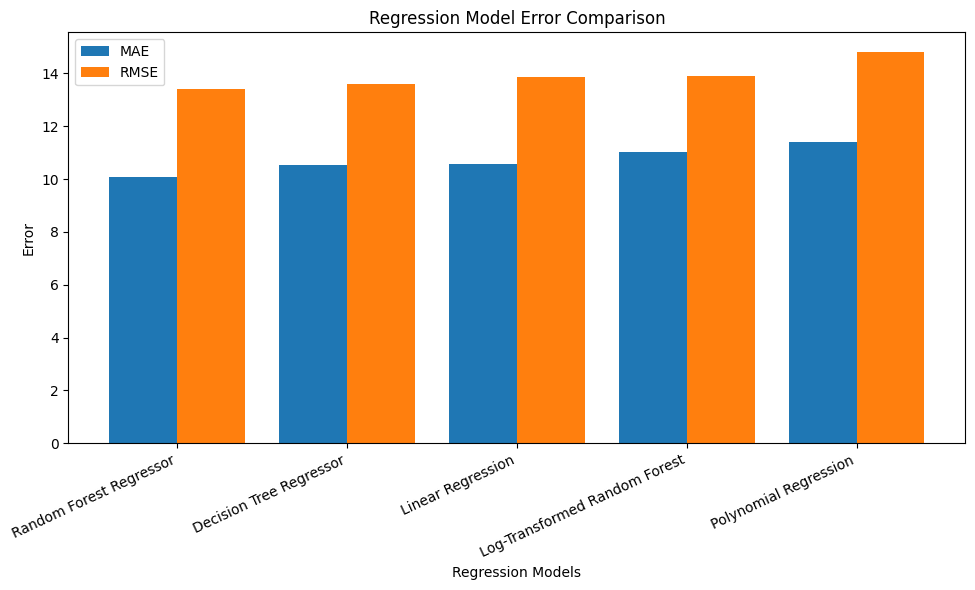

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Convert regression results into dataframe
reg_df = pd.DataFrame(regression_results)

# Sort by RMSE
reg_df = reg_df.sort_values("RMSE")

# Plot
plt.figure(figsize=(10, 6))

x = np.arange(len(reg_df))

plt.bar(x - 0.2, reg_df["MAE"], width=0.4, label="MAE")
plt.bar(x + 0.2, reg_df["RMSE"], width=0.4, label="RMSE")

plt.xticks(x, reg_df["Model"], rotation=25, ha="right")

plt.xlabel("Regression Models")
plt.ylabel("Error")
plt.title("Regression Model Error Comparison")

plt.legend()

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 8B. OLS REGRESSION USING STATSMODELS
# ============================================================
# OLS is used here for interpretation: which audio features are statistically related to popularity.
# This is separate from the tuned ML models above.

ols_data = songs_df[numeric_features + [POPULARITY_COL]].dropna()
X_ols = sm.add_constant(ols_data[numeric_features])
y_ols = ols_data[POPULARITY_COL]

ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())

print("\nOLS Interpretation Help:")
print("- Low p-value (< 0.05): feature has statistically significant relationship with popularity.")
print("- Positive coefficient: higher feature value is associated with higher popularity.")
print("- Negative coefficient: higher feature value is associated with lower popularity.")
print("- Low R-squared means audio features alone do not explain most popularity variation.")

                            OLS Regression Results                            
Dep. Variable:                    pop   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     7.719
Date:                Fri, 01 May 2026   Prob (F-statistic):           1.20e-11
Time:                        19:03:53   Log-Likelihood:                -2370.2
No. Observations:                 587   AIC:                             4762.
Df Residuals:                     576   BIC:                             4811.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2528.4966    481.378     -5.253      0.0

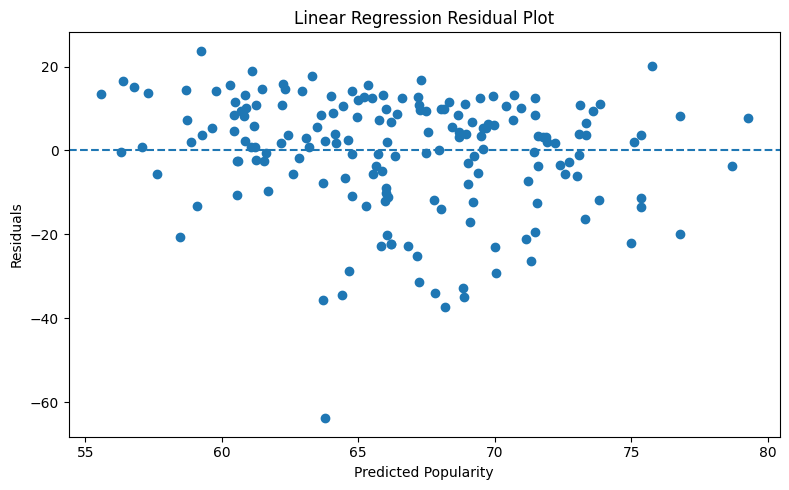

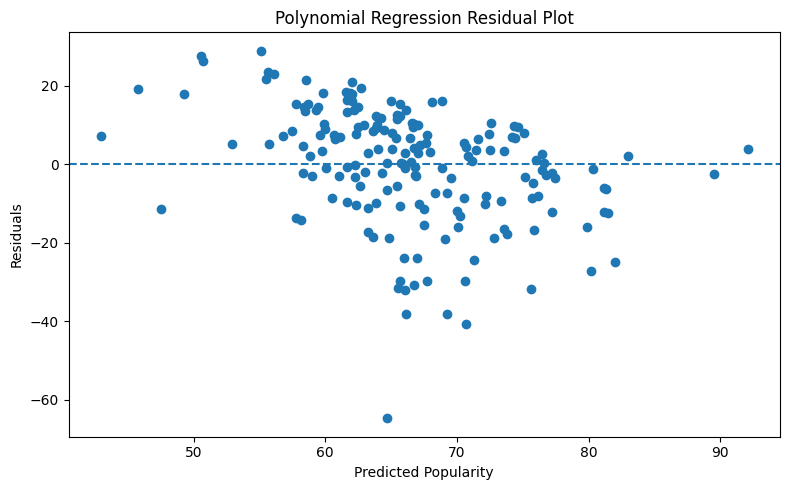

In [15]:

# ============================================================
# 9. REGRESSION RESIDUAL PLOTS
# ============================================================
residuals_lin = y_test_reg - y_pred_lin
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_lin, residuals_lin)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Popularity")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")
plt.tight_layout()
plt.show()

residuals_poly = y_test_reg - y_pred_poly
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_poly, residuals_poly)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Popularity")
plt.ylabel("Residuals")
plt.title("Polynomial Regression Residual Plot")
plt.tight_layout()
plt.show()


## Predictive Modeling: General Preference Prediction

In [16]:
# ============================================================
# 10. CLASSIFICATION: REAL USER PREFERENCE PREDICTION
# Fixes included here:
# 1. Uses ratings_df["liked"] instead of popularity proxy
# 2. Scales features properly for Logistic Regression and SVM
# 3. Tunes models using GridSearchCV
# 4. Handles class imbalance using class_weight="balanced"
# ============================================================

preference_df = ratings_df.merge(
    songs_df[["song_id"] + numeric_features],
    on="song_id",
    how="inner"
).dropna(subset=["liked"])

X_cls = preference_df[numeric_features]
y_cls = preference_df["liked"].astype(int)

print("Class distribution before modeling:")
display(y_cls.value_counts().rename(index={0: "Not Liked", 1: "Liked"}))
print("Class percentage:")
display((y_cls.value_counts(normalize=True) * 100).round(2).rename(index={0: "Not Liked", 1: "Liked"}))

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls,
    test_size=0.30,
    random_state=42,
    stratify=y_cls
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classification_models = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1, 10]
        }
    },
    "Decision Tree": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))
        ]),
        "params": {
            "model__max_depth": [3, 5, 8, None],
            "model__min_samples_split": [2, 5, 10]
        }
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(class_weight="balanced", random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 5]
        }
    },
    "SVM": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, class_weight="balanced", random_state=42))
        ]),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale", "auto"]
        }
    }
}

classification_results = []
best_pref_model = None
best_cls_name = None
best_recall = -1
best_precision = -1

for name, setup in classification_models.items():
    grid = GridSearchCV(
        estimator=setup["pipeline"],
        param_grid=setup["params"],
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )
    grid.fit(X_train_cls, y_train_cls)

    pred = grid.predict(X_test_cls)
    acc = accuracy_score(y_test_cls, pred)
    prec = precision_score(y_test_cls, pred, zero_division=0)
    rec = recall_score(y_test_cls, pred, zero_division=0)
    f1 = (2 * prec * rec) / (prec + rec + 1e-9)

    classification_results.append({
        "Model": name,
        "Best Parameters": grid.best_params_,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "F1 CV Score": grid.best_score_
    })

    # choose best model using recall first, then precision
    if (rec > best_recall) or (rec == best_recall and prec > best_precision):
        best_recall = rec
        best_precision = prec
        best_pref_model = grid.best_estimator_
        best_cls_name = name

classification_results_df = pd.DataFrame(classification_results).sort_values(
    ["Recall", "Precision", "Accuracy"], ascending=False
)
display(classification_results_df)
print("Best preference model:", best_cls_name)


Class distribution before modeling:


liked
Liked        424
Not Liked    395
Name: count, dtype: int64

Class percentage:


liked
Liked        51.77
Not Liked    48.23
Name: proportion, dtype: float64

,Model,Best Parameters,Accuracy,Precision,Recall,F1 Score,F1 CV Score
1,Decision Tree,"{'model__max_depth': 8, 'model__min_samples_sp...",0.577236,0.573248,0.708661,0.633803,0.554200
2,Random Forest,"{'model__max_depth': 10, 'model__min_samples_s...",0.528455,0.537931,0.614173,0.573529,0.558085
3,SVM,"{'model__C': 10, 'model__gamma': 'scale', 'mod...",0.548780,0.558824,0.598425,0.577947,0.549808
0,Logistic Regression,{'model__C': 0.01},0.455285,0.472000,0.464567,0.468254,0.509065


Best preference model: Decision Tree


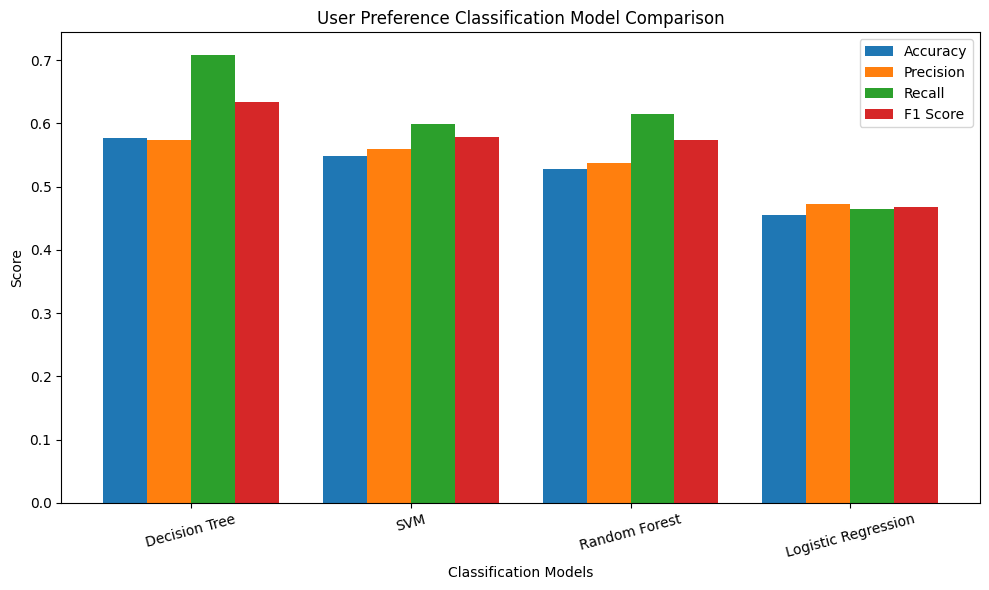

In [17]:
# ============================================================
# 10B. USER PREFERENCE CLASSIFICATION MODEL COMPARISON GRAPH
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

plot_df = classification_results_df.sort_values("F1 Score", ascending=False)

x = np.arange(len(plot_df["Model"]))
width = 0.2

plt.figure(figsize=(10, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i * width,
        plot_df[metric],
        width=width,
        label=metric
    )

plt.xticks(
    x + width * 1.5,
    plot_df["Model"],
    rotation=15
)

plt.xlabel("Classification Models")
plt.ylabel("Score")
plt.title("User Preference Classification Model Comparison")

plt.legend()
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.58      0.44      0.50       119
           1       0.57      0.71      0.63       127

    accuracy                           0.58       246
   macro avg       0.58      0.57      0.57       246
weighted avg       0.58      0.58      0.57       246



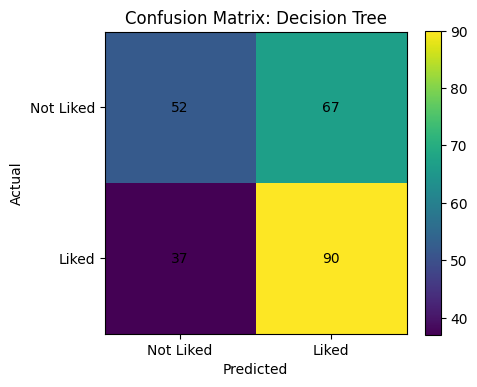

In [18]:

# ============================================================
# 11. CONFUSION MATRIX FOR BEST CLASSIFIER
# ============================================================
best_pred = best_pref_model.predict(X_test_cls)
print(classification_report(y_test_cls, best_pred, zero_division=0))

cm = confusion_matrix(y_test_cls, best_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Confusion Matrix: {best_cls_name}")
plt.colorbar()
plt.xticks([0,1], ["Not Liked", "Liked"])
plt.yticks([0,1], ["Not Liked", "Liked"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### Genre Classification

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.597561,0.433026,0.597561,0.480342
1,Random Forest,0.603659,0.434193,0.603659,0.480247
2,SVM,0.597561,0.357079,0.597561,0.447030


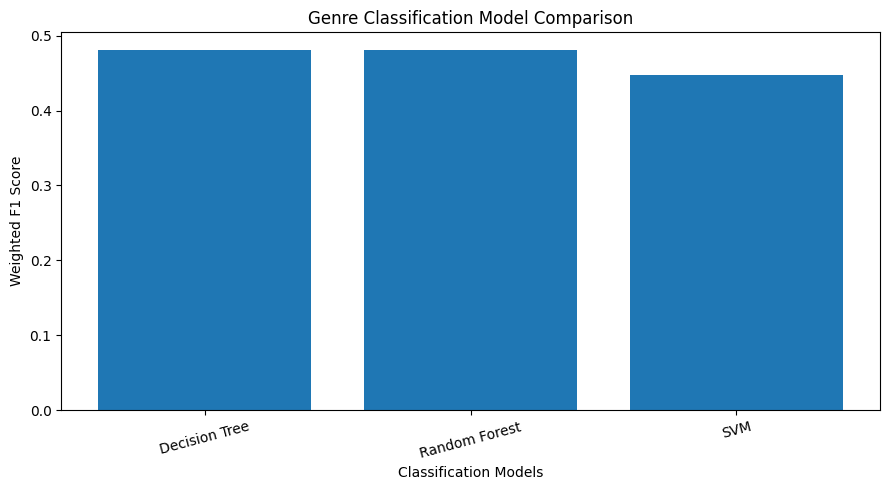

In [19]:
# ============================================================
# 12. GENRE CLASSIFICATION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Prepare Genre Dataset ----------------

genre_df = songs_df.copy()

genre_df = genre_df.dropna(subset=[GENRE_COL])

genre_counts = genre_df[GENRE_COL].value_counts()
valid_genres = genre_counts[genre_counts >= 3].index

genre_df = genre_df[genre_df[GENRE_COL].isin(valid_genres)]

X_genre = genre_df[numeric_features]
y_genre = genre_df[GENRE_COL]

# ---------------- Encode Genres ----------------

le = LabelEncoder()
y_genre_encoded = le.fit_transform(y_genre)

# ---------------- Train-Test Split ----------------

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_genre,
    y_genre_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_genre_encoded
)

# ---------------- Genre Classification Models ----------------

genre_models = {
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(max_depth=6, random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),

    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            random_state=42
        ))
    ])
}

# ---------------- Train and Evaluate Models ----------------

genre_results = []

for name, model in genre_models.items():

    model.fit(X_train_g, y_train_g)

    pred = model.predict(X_test_g)

    genre_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_g, pred),
        "Precision": precision_score(
            y_test_g,
            pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_g,
            pred,
            average="weighted",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test_g,
            pred,
            average="weighted",
            zero_division=0
        )
    })

# ---------------- Results Table ----------------

genre_results_df = pd.DataFrame(genre_results)

genre_results_df = genre_results_df.sort_values(
    by="F1 Score",
    ascending=False
)

display(genre_results_df)

# ============================================================
# GENRE CLASSIFICATION PERFORMANCE GRAPH
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    genre_results_df["Model"],
    genre_results_df["F1 Score"]
)

plt.xlabel("Classification Models")
plt.ylabel("Weighted F1 Score")

plt.title("Genre Classification Model Comparison")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

Best genre model: Decision Tree
                           precision    recall  f1-score   support

                  art pop       0.00      0.00      0.00         2
              atl hip hop       0.00      0.00      0.00         1
         australian dance       0.00      0.00      0.00         2
           australian pop       0.00      0.00      0.00         1
            barbadian pop       0.00      0.00      0.00         5
                 big room       0.00      0.00      0.00         3
                 boy band       0.00      0.00      0.00         5
             british soul       0.00      0.00      0.00         3
canadian contemporary r&b       0.00      0.00      0.00         2
             canadian pop       0.50      0.11      0.18         9
            colombian pop       0.00      0.00      0.00         1
               complextro       0.00      0.00      0.00         2
                dance pop       0.62      0.97      0.76        98
                      edm    

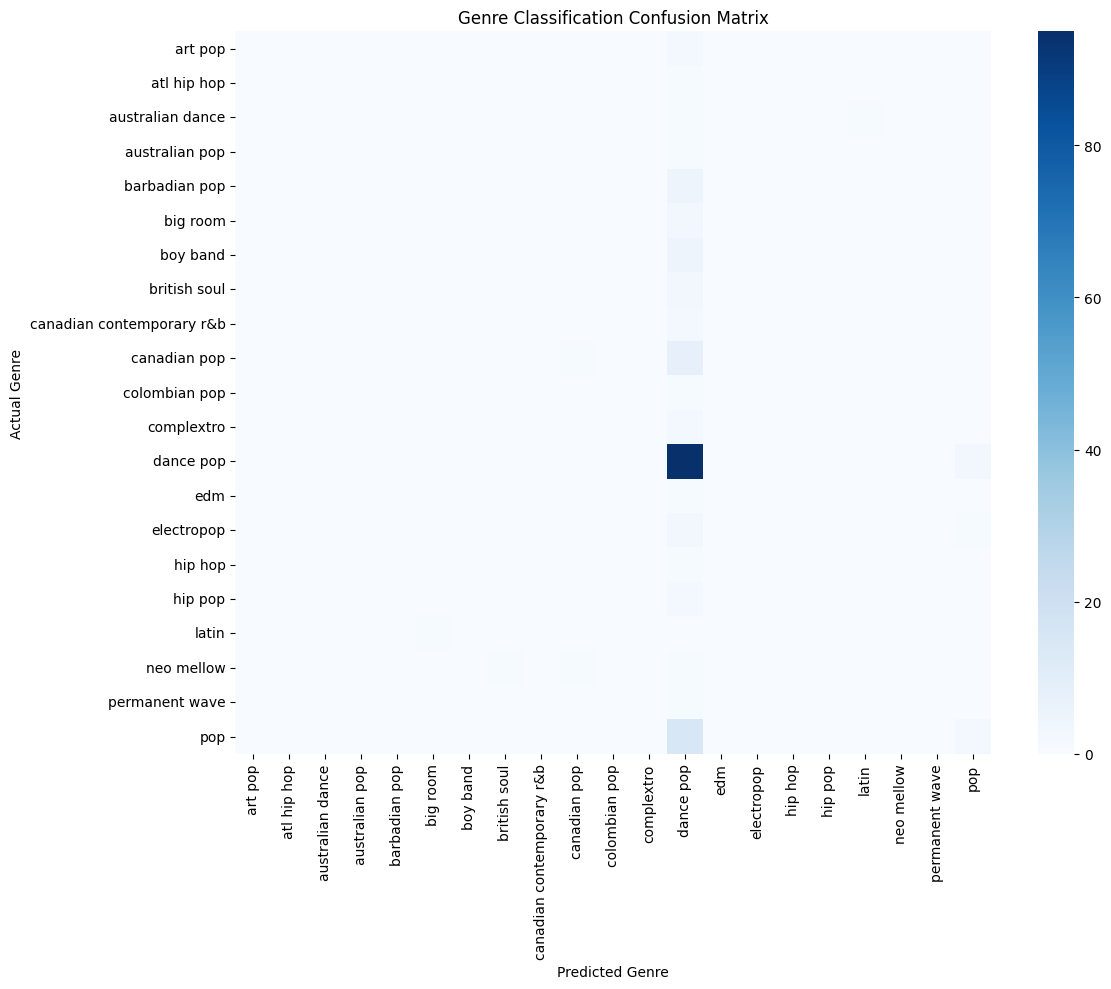

In [20]:
# ============================================================
# 12B. GENRE CLASSIFICATION CONFUSION MATRIX AND REPORT
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

best_genre_model_name = genre_results_df.iloc[0]["Model"]
best_genre_model = genre_models[best_genre_model_name]

y_pred_genre = best_genre_model.predict(X_test_g)

print("Best genre model:", best_genre_model_name)

print(
    classification_report(
        y_test_g,
        y_pred_genre,
        labels=range(len(le.classes_)),
        target_names=le.classes_,
        zero_division=0
    )
)

cm_genre = confusion_matrix(
    y_test_g,
    y_pred_genre,
    labels=range(len(le.classes_))
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_genre,
    annot=False,
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Genre Classification Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Feature Importance

,Feature,Importance
0,year,0.155902
1,bpm,0.116785
2,nrgy,0.114436
7,dur,0.104883
3,dnce,0.100008
6,val,0.092823
5,live,0.082571
8,acous,0.081957
9,spch,0.079514
4,db,0.071121


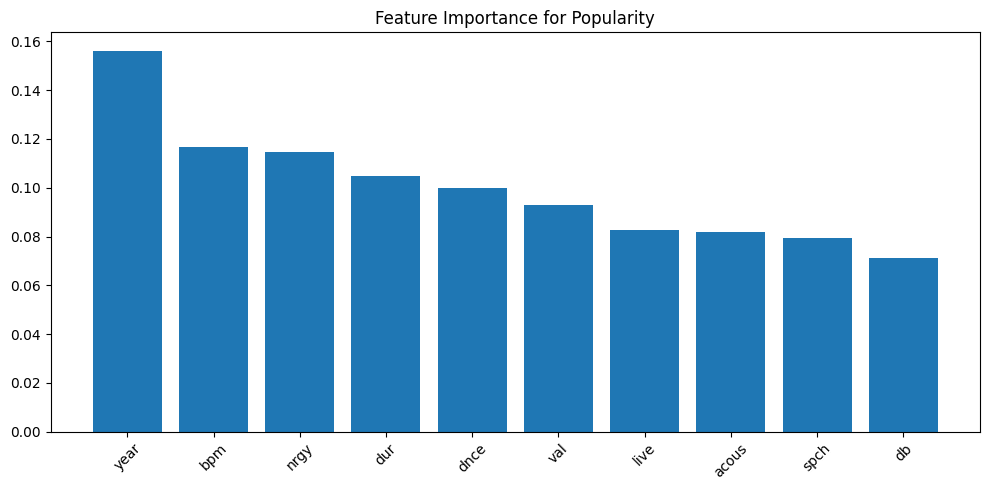

In [21]:

# ============================================================
# 13. FEATURE IMPORTANCE FOR POPULARITY
# ============================================================
rf_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

rf_reg.fit(X_reg, y_reg)

importance_df = pd.DataFrame({
    "Feature": numeric_features,
    "Importance": rf_reg.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df)

plt.figure(figsize=(10, 5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance for Popularity")
plt.tight_layout()
plt.show()


,Feature,Importance
6,val,0.125742
7,dur,0.119448
2,nrgy,0.115718
5,live,0.113056
3,dnce,0.109479
1,bpm,0.108049
8,acous,0.097564
0,year,0.075553
9,spch,0.074111
4,db,0.061279


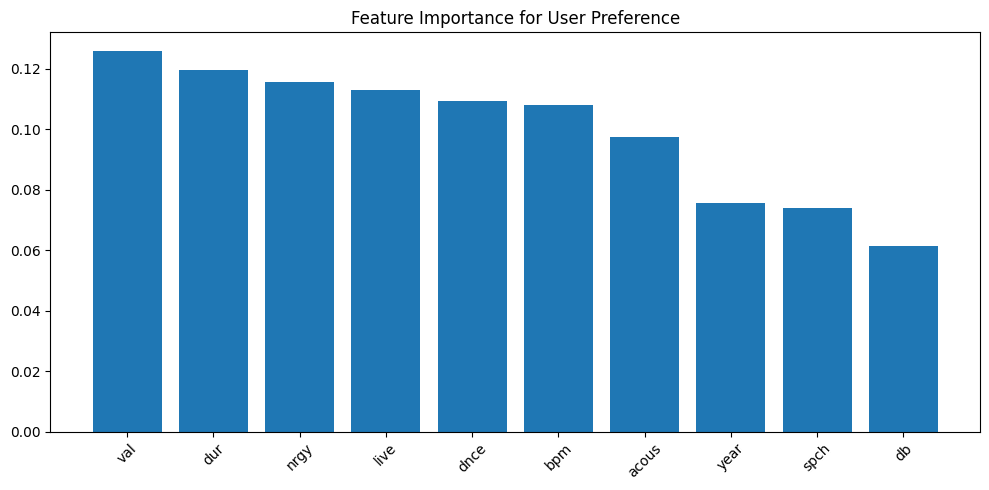

In [22]:
# ============================================================
# 13B. FEATURE IMPORTANCE FOR USER PREFERENCE
# ============================================================
rf_pref_importance = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ))
])

rf_pref_importance.fit(X_cls, y_cls)

preference_importance_df = pd.DataFrame({
    "Feature": numeric_features,
    "Importance": rf_pref_importance.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False)

display(preference_importance_df)

plt.figure(figsize=(10, 5))
plt.bar(preference_importance_df["Feature"], preference_importance_df["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance for User Preference")
plt.tight_layout()
plt.show()


## Real User Behavior Analysis

This section uses the actual frontend-generated CSV files. Run the Streamlit app first and create/listen/rate songs, then rerun this notebook.


In [23]:

# ============================================================
# 14. REAL USER DATA SUMMARY
# ============================================================
print("Total real users:", users_df["user_id"].nunique() if not users_df.empty else 0)
print("Total listening records:", len(history_df))
print("Total ratings:", len(ratings_df))
print("Total recommendation logs:", len(recommendation_logs_df))

display(users_df.head())
display(user_pref_df.head())
display(history_df.head())
display(ratings_df.head())


Total real users: 51
Total listening records: 1253
Total ratings: 819
Total recommendation logs: 188


,user_id,username,email,created_at
0,1,Shreya,shreya.mondal@gmail.com,2026-03-14 15:45:26.136933
1,2,Alex,alexjohnson@yahoo.com,2026-04-22 15:45:26.139048
2,3,Maya,maya.patel@hotmail.com,2026-04-28 15:45:26.139048
3,4,Noah,noah.smith@yahoo.com,2026-04-16 15:45:26.139048
4,5,Sara,sara.khan@yahoo.com,2026-03-16 15:45:26.139048


,user_id,preferred_genres,created_at,updated_at
0,1,complextro;canadian pop,2026-03-29 15:45:26.144428,NaN
1,2,boy band;edm,2026-03-30 15:45:26.144428,NaN
2,3,tropical house;australian pop,2026-03-15 15:45:26.144428,NaN
3,4,french indie pop;australian dance;acoustic pop...,2026-04-18 15:45:26.144428,NaN
4,5,barbadian pop;edm,2026-04-03 15:45:26.144428,NaN


,history_id,user_id,title,artist,top_genre,time_period,mood,listened_at,song_id
0,1,1,Rock N Roll,Avril Lavigne,canadian pop,Evening,NaN,2026-03-12 02:45:26.154604,177.0
1,2,1,Let Me Love You,DJ Snake,electronic trap,Afternoon,NaN,2026-04-14 10:45:26.155597,436.0
2,3,1,True Colors,Zedd,complextro,Morning,NaN,2026-03-08 00:45:26.157244,415.0
3,4,1,Baby,Justin Bieber,canadian pop,Afternoon,NaN,2026-04-17 15:45:26.163366,6.0
4,5,1,Treat You Better,Shawn Mendes,canadian pop,Morning,NaN,2026-03-13 07:45:26.165382,434.0


,rating_id,user_id,title,artist,top_genre,rating,liked,time_period,rated_at,song_id
0,1,1,True Colors,Zedd,complextro,4,1,Morning,2026-03-10 01:45:26.163366,415
1,2,1,Treat You Better,Shawn Mendes,canadian pop,4,1,Morning,2026-03-30 03:45:26.165382,434
2,3,1,Higher,Carly Rae Jepsen,canadian pop,4,1,Evening,2026-04-15 10:45:26.169413,421
3,4,1,Stay,Zedd,complextro,5,1,Morning,2026-03-16 05:45:26.171164,440
4,5,1,Stay The Night - Featuring Hayley Williams Of ...,Zedd,complextro,4,1,Morning,2026-04-28 17:45:26.172681,239


,user_id,preferred_genre
0,1,complextro
1,1,canadian pop
2,2,boy band
3,2,edm
4,3,tropical house
...,...,...
145,49,moroccan pop
146,49,indie pop
147,50,art pop
148,50,colombian pop


preferred_genre
british soul                 7
barbadian pop                7
tropical house               6
pop                          6
canadian pop                 6
edm                          6
house                        5
permanent wave               5
dance pop                    5
australian pop               4
neo mellow                   4
acoustic pop                 4
metropopolis                 4
brostep                      4
indie pop                    4
hip hop                      3
baroque pop                  3
irish singer-songwriter      3
moroccan pop                 3
electro                      3
belgian edm                  3
folk-pop                     3
atl hip hop                  3
danish pop                   3
complextro                   3
art pop                      3
electronic trap              3
french indie pop             3
electropop                   3
canadian latin               3
hip pop                      3
canadian contemporary r

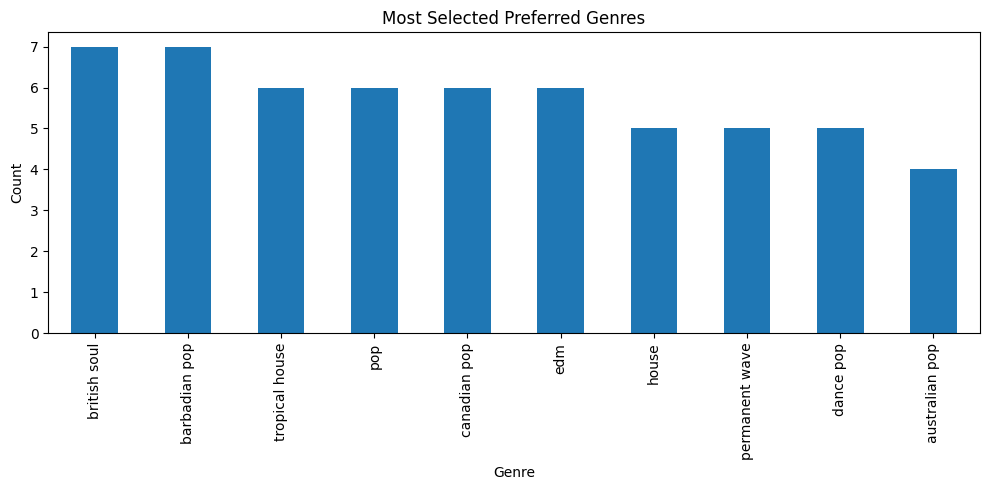

In [24]:

# ============================================================
# 15. USER PREFERRED GENRES
# ============================================================
if user_pref_df.empty:
    print("No user preferences collected yet.")
else:
    expanded_prefs = []
    for _, row in user_pref_df.iterrows():
        for genre in split_genres(row["preferred_genres"]):
            expanded_prefs.append({"user_id": row["user_id"], "preferred_genre": genre})

    expanded_prefs_df = pd.DataFrame(expanded_prefs)
    display(expanded_prefs_df)

    pref_counts = expanded_prefs_df["preferred_genre"].value_counts()
    display(pref_counts)

    plt.figure(figsize=(10, 5))
    pref_counts.head(10).plot(kind="bar")
    plt.title("Most Selected Preferred Genres")
    plt.xlabel("Genre")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


,time_period,top_genre,count
23,Afternoon,dance pop,66
16,Afternoon,canadian pop,32
44,Afternoon,pop,25
6,Afternoon,barbadian pop,16
11,Afternoon,british soul,13
...,...,...,...
148,Night,contemporary country,1
150,Night,downtempo,1
153,Night,escape room,1
155,Night,french indie pop,1


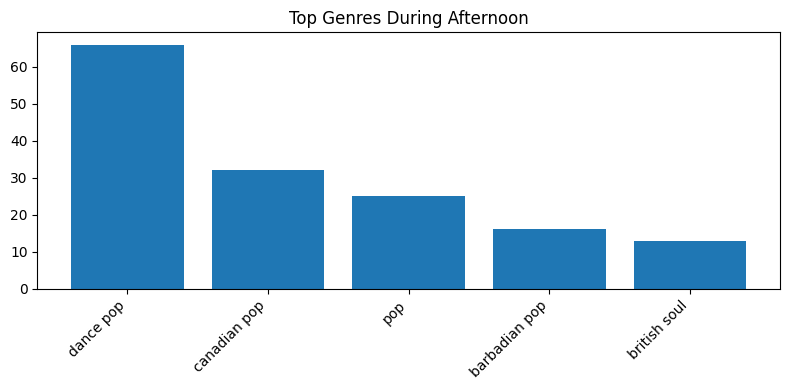

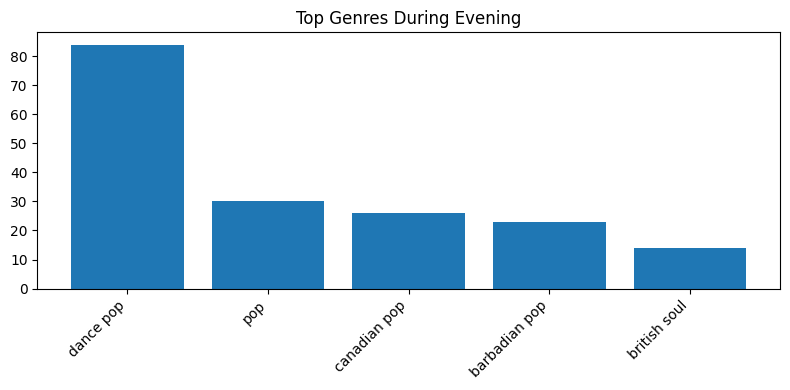

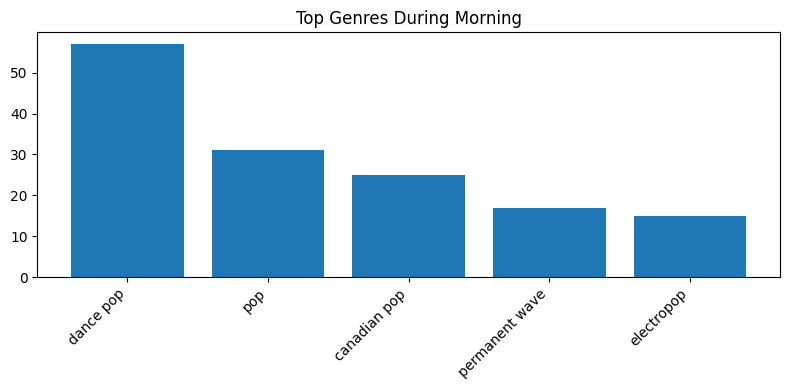

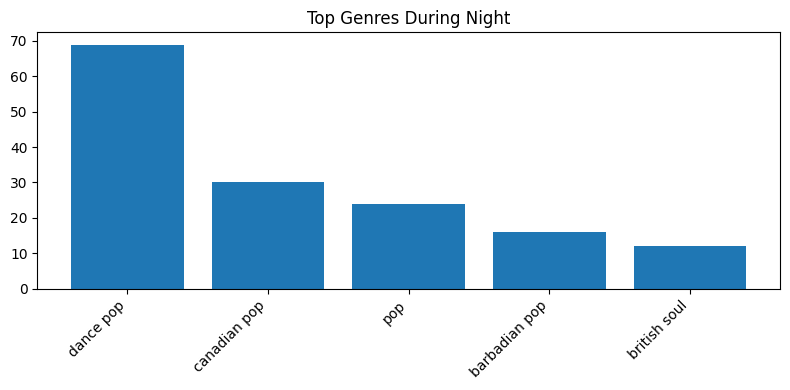

In [25]:

# ============================================================
# 16. LISTENING HISTORY BY TIME AND GENRE
# ============================================================
if history_df.empty:
    print("No listening history collected yet.")
else:
    time_genre_counts = history_df.groupby(["time_period", GENRE_COL]).size().reset_index(name="count")
    time_genre_counts = time_genre_counts.sort_values(["time_period", "count"], ascending=[True, False])
    display(time_genre_counts)

    top_time_genres = time_genre_counts.groupby("time_period").head(5)
    for period in top_time_genres["time_period"].unique():
        subset = top_time_genres[top_time_genres["time_period"] == period]
        plt.figure(figsize=(8, 4))
        plt.bar(subset[GENRE_COL], subset["count"])
        plt.title(f"Top Genres During {period}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


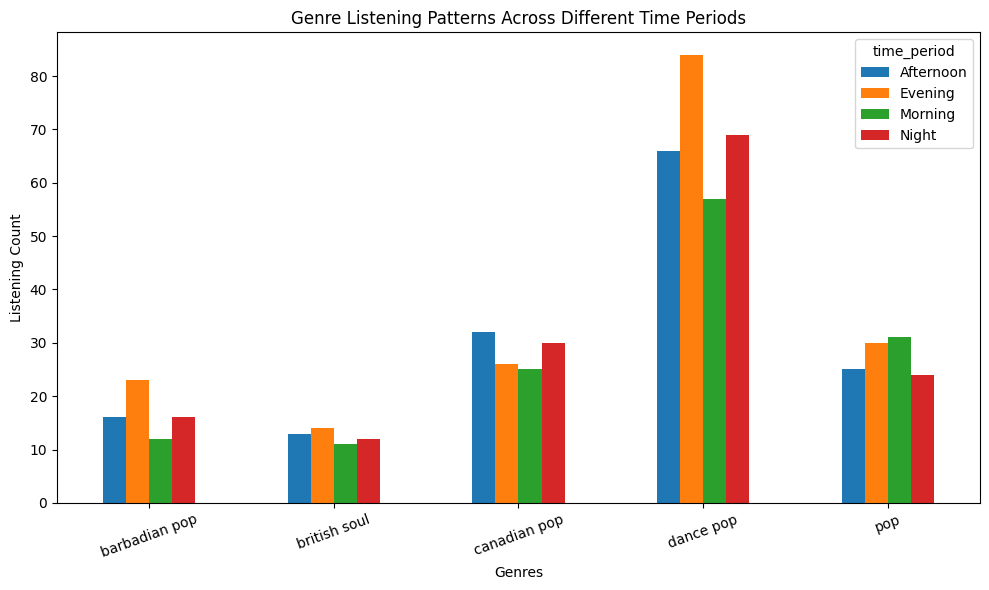

In [26]:
# ============================================================
# GROUPED GENRE LISTENING CHART BY TIME PERIOD
# ============================================================

# Count genre occurrences by time period
genre_time_counts = (
    history_df.groupby(["time_period", GENRE_COL])
    .size()
    .reset_index(name="Count")
)

# Keep top genres overall for readability
top_genres = (
    genre_time_counts.groupby(GENRE_COL)["Count"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

filtered_df = genre_time_counts[
    genre_time_counts[GENRE_COL].isin(top_genres)
]

# Pivot for grouped chart
pivot_df = filtered_df.pivot(
    index=GENRE_COL,
    columns="time_period",
    values="Count"
).fillna(0)

# Plot
pivot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Genres")
plt.ylabel("Listening Count")

plt.title("Genre Listening Patterns Across Different Time Periods")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

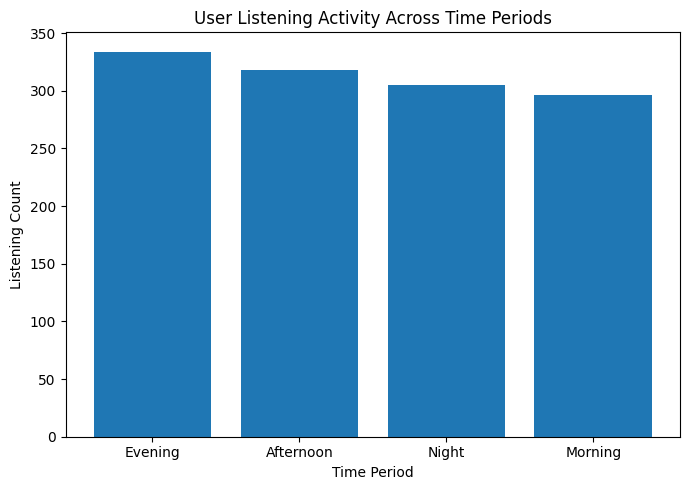

In [27]:
# ============================================================
# TIME-OF-DAY LISTENING BEHAVIOR
# ============================================================

time_counts = history_df["time_period"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    time_counts.index,
    time_counts.values
)

plt.xlabel("Time Period")
plt.ylabel("Listening Count")

plt.title("User Listening Activity Across Time Periods")

plt.tight_layout()

plt.show()

Average rating: 3.46


,count,mean
top_genre,,
danish pop,2,4.500000
escape room,3,4.333333
edm,14,4.214286
metropopolis,10,4.100000
celtic rock,3,4.000000
french indie pop,3,4.000000
brostep,8,4.000000
irish singer-songwriter,2,4.000000
electro house,2,4.000000


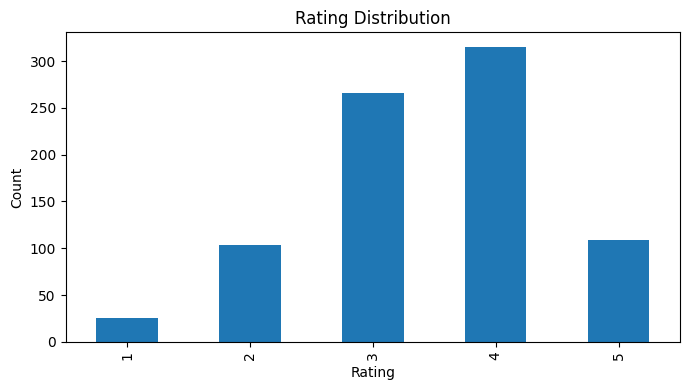

Most liked genres:


top_genre
pop                          52
dance pop                    51
canadian pop                 49
barbadian pop                27
british soul                 23
electropop                   17
art pop                      15
permanent wave               15
neo mellow                   13
hip hop                      13
edm                          12
colombian pop                11
hip pop                      10
australian pop               10
metropopolis                  9
baroque pop                   9
big room                      7
belgian edm                   7
canadian contemporary r&b     6
complextro                    6
latin                         6
tropical house                6
brostep                       5
boy band                      5
house                         5
acoustic pop                  4
australian dance              3
moroccan pop                  3
french indie pop              3
atl hip hop                   3
celtic rock                   

In [28]:

# ============================================================
# 17. RATINGS ANALYSIS
# ============================================================
if ratings_df.empty:
    print("No ratings collected yet.")
else:
    print("Average rating:", round(ratings_df["rating"].mean(), 2))
    display(ratings_df.groupby(GENRE_COL)["rating"].agg(["count", "mean"]).sort_values("mean", ascending=False))

    plt.figure(figsize=(7, 4))
    ratings_df["rating"].value_counts().sort_index().plot(kind="bar")
    plt.title("Rating Distribution")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    liked_genres = ratings_df[ratings_df["liked"] == 1][GENRE_COL].value_counts()
    print("Most liked genres:")
    display(liked_genres)


## Personalized Recommendation Logic Using Real Users

In [29]:
# ============================================================
# 18. PERSONALIZED RECOMMENDATION FUNCTIONS
# Fixes included here:
# 1. Defines recommend_for_real_user before it is called
# 2. Adds user-user collaborative filtering: "Users like you also liked"
# 3. Adds item-item collaborative filtering: "People who liked this song also liked"
# 4. Keeps genre, time-period, regression, and classification scoring
# ============================================================

def get_user_preferred_genres(user_id):
    pref = user_pref_df[user_pref_df["user_id"] == user_id]
    if pref.empty:
        return []
    return split_genres(pref.iloc[0]["preferred_genres"])

def get_top_user_genres_for_time(user_id, time_period, fallback_genres=None):
    fallback_genres = fallback_genres or []

    h = history_df[(history_df["user_id"] == user_id) & (history_df["time_period"] == time_period)]
    r = ratings_df[(ratings_df["user_id"] == user_id) & (ratings_df["time_period"] == time_period)]

    frames = []
    if not h.empty and GENRE_COL in h.columns:
        frames.append(h[[GENRE_COL]].rename(columns={GENRE_COL: "genre"}))
    if not r.empty and GENRE_COL in r.columns:
        expanded = []
        for _, row in r.iterrows():
            weight = 2 if int(row.get("liked", 0)) == 1 else 1
            for _ in range(weight):
                expanded.append({"genre": row[GENRE_COL]})
        if expanded:
            frames.append(pd.DataFrame(expanded))

    if frames:
        combined = pd.concat(frames, ignore_index=True)
        counts = combined["genre"].value_counts()
        if not counts.empty:
            return counts.head(3).index.tolist()

    return fallback_genres[:3]

def build_user_profile(user_id, time_period):
    user_ratings = ratings_df[(ratings_df["user_id"] == user_id) & (ratings_df["liked"] == 1)]
    same_time_history = history_df[(history_df["user_id"] == user_id) & (history_df["time_period"] == time_period)]

    key_frames = []
    if not user_ratings.empty and {TRACK_COL, ARTIST_COL}.issubset(user_ratings.columns):
        key_frames.append(user_ratings[[TRACK_COL, ARTIST_COL]])
    if not same_time_history.empty and {TRACK_COL, ARTIST_COL}.issubset(same_time_history.columns):
        key_frames.append(same_time_history[[TRACK_COL, ARTIST_COL]])

    if not key_frames:
        return None

    user_song_keys = pd.concat(key_frames, ignore_index=True).drop_duplicates()
    user_song_data = songs_df.merge(user_song_keys, on=[TRACK_COL, ARTIST_COL], how="inner")

    if user_song_data.empty:
        return None

    return user_song_data[numeric_features].mean()

# ------------------------------------------------------------
# Collaborative filtering helpers
# ------------------------------------------------------------
def build_user_item_matrix():
    if ratings_df.empty or not {"user_id", "song_id", "rating"}.issubset(ratings_df.columns):
        return pd.DataFrame()

    return ratings_df.pivot_table(
        index="user_id",
        columns="song_id",
        values="rating",
        aggfunc="mean"
    ).fillna(0)

user_item_matrix = build_user_item_matrix()

if user_item_matrix.empty:
    user_similarity_df = pd.DataFrame()
    item_similarity_df = pd.DataFrame()
else:
    user_similarity_df = pd.DataFrame(
        cosine_similarity(user_item_matrix),
        index=user_item_matrix.index,
        columns=user_item_matrix.index
    )
    item_similarity_df = pd.DataFrame(
        cosine_similarity(user_item_matrix.T),
        index=user_item_matrix.columns,
        columns=user_item_matrix.columns
    )

def get_similar_users(user_id, top_n=5):
    """User-user collaborative filtering: find users with similar rating behavior."""
    if user_similarity_df.empty or user_id not in user_similarity_df.index:
        return pd.Series(dtype=float)
    return user_similarity_df.loc[user_id].drop(index=user_id, errors="ignore").sort_values(ascending=False).head(top_n)

def get_user_user_recommendations(user_id, top_n=10):
    """Users like you also liked..."""
    if user_similarity_df.empty or user_id not in user_similarity_df.index:
        return []

    similar_users = get_similar_users(user_id, top_n=5)
    if similar_users.empty:
        return []

    user_seen = set(ratings_df.loc[ratings_df["user_id"] == user_id, "song_id"])
    sim_user_ids = similar_users.index.tolist()

    candidate_ratings = ratings_df[
        (ratings_df["user_id"].isin(sim_user_ids)) &
        (~ratings_df["song_id"].isin(user_seen))
    ].copy()

    if candidate_ratings.empty:
        return []

    # Weight ratings by user similarity
    candidate_ratings["similarity_weight"] = candidate_ratings["user_id"].map(similar_users)
    candidate_ratings["weighted_rating"] = candidate_ratings["rating"] * candidate_ratings["similarity_weight"]

    rec_scores = (
        candidate_ratings.groupby("song_id")
        .agg(weighted_rating_sum=("weighted_rating", "sum"), similarity_sum=("similarity_weight", "sum"))
    )
    rec_scores["cf_user_score"] = rec_scores["weighted_rating_sum"] / rec_scores["similarity_sum"]

    return rec_scores.sort_values("cf_user_score", ascending=False).head(top_n).index.tolist()

def get_item_item_recommendations(user_id=None, song_id=None, top_n=10):
    """People who liked this song also liked..."""
    if item_similarity_df.empty:
        return []

    seed_song_ids = []
    if song_id is not None and song_id in item_similarity_df.index:
        seed_song_ids = [song_id]
    elif user_id is not None:
        liked_songs = ratings_df[
            (ratings_df["user_id"] == user_id) &
            (ratings_df["liked"] == 1)
        ]["song_id"].tolist()
        seed_song_ids = [s for s in liked_songs if s in item_similarity_df.index]

    if not seed_song_ids:
        return []

    seen = set(ratings_df.loc[ratings_df["user_id"] == user_id, "song_id"]) if user_id is not None else set(seed_song_ids)

    item_scores = item_similarity_df.loc[seed_song_ids].mean(axis=0)
    item_scores = item_scores.drop(index=list(seen), errors="ignore")

    return item_scores.sort_values(ascending=False).head(top_n).index.tolist()

def create_recommendation_reason(row, time_period, has_profile):
    reasons = []

    if row.get("cf_user_match", 0) == 1:
        reasons.append("users with similar ratings also liked this song")
    if row.get("cf_item_match", 0) == 1:
        reasons.append("people who liked similar songs also liked this")
    if row.get("genre_match", 0) == 1:
        reasons.append("matches the user's selected preferred genres")
    if row.get("time_genre_match", 0) == 1:
        reasons.append(f"matches genres this user listens to during {time_period}")
    if has_profile and row.get("user_similarity", 0) >= 0.75:
        reasons.append("audio features are similar to songs the user liked or listened to")
    if row.get("preference_probability", 0) >= 0.70:
        reasons.append("classification model predicts high like probability")
    if row.get("predicted_pop", 0) >= 70:
        reasons.append("regression model predicts strong popularity")
    if row.get("dnce", 0) >= 70:
        reasons.append("high danceability")
    if row.get("nrgy", 0) >= 75:
        reasons.append("high energy")
    if row.get("acous", 0) >= 45 and time_period in ["Morning", "Evening"]:
        reasons.append("acoustic/softer feel fits the time period")
    if row.get("val", 0) >= 60:
        reasons.append("positive mood/valence")

    if not reasons:
        reasons.append("balanced score from user behavior, model prediction, and audio features")

    return "Recommended because " + "; ".join(reasons) + "."

def recommend_for_real_user(user_id, time_period="Morning", top_n=10):
    """Main recommendation function used by the notebook and frontend logic."""
    temp = songs_df.copy()

    preferred_genres = get_user_preferred_genres(user_id)
    time_genres = get_top_user_genres_for_time(user_id, time_period, preferred_genres)

    profile = build_user_profile(user_id, time_period)
    has_profile = profile is not None

    feature_matrix = temp[numeric_features].fillna(temp[numeric_features].median())

    if has_profile:
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(feature_matrix)
        scaled_profile = scaler.transform(pd.DataFrame([profile], columns=numeric_features))
        temp["user_similarity"] = cosine_similarity(scaled_features, scaled_profile).flatten()
        temp["user_similarity"] = (temp["user_similarity"] + 1) / 2
    else:
        temp["user_similarity"] = 0.50

    # Model scores
    temp["predicted_pop"] = best_reg_model.predict(temp[numeric_features]).clip(0, 100)

    if hasattr(best_pref_model, "predict_proba"):
        temp["preference_probability"] = best_pref_model.predict_proba(temp[numeric_features])[:, 1]
    else:
        temp["preference_probability"] = best_pref_model.predict(temp[numeric_features])

    # Rule-based/user-context scores
    temp["genre_match"] = temp[GENRE_COL].isin(preferred_genres).astype(int)
    temp["time_genre_match"] = temp[GENRE_COL].isin(time_genres).astype(int)
    temp["time_score"] = temp.apply(lambda row: get_time_feature_score(row, time_period), axis=1)

    # Collaborative filtering scores
    user_user_song_ids = set(get_user_user_recommendations(user_id, top_n=25))
    item_item_song_ids = set(get_item_item_recommendations(user_id=user_id, top_n=25))

    temp["cf_user_match"] = temp["song_id"].isin(user_user_song_ids).astype(int) if "song_id" in temp.columns else 0
    temp["cf_item_match"] = temp["song_id"].isin(item_item_song_ids).astype(int) if "song_id" in temp.columns else 0

    # Remove songs already seen/rated/listened by the user
    already_seen_frames = []
    if not history_df.empty and {TRACK_COL, ARTIST_COL}.issubset(history_df.columns):
        already_seen_frames.append(history_df[history_df["user_id"] == user_id][[TRACK_COL, ARTIST_COL]])
    if not ratings_df.empty and {TRACK_COL, ARTIST_COL}.issubset(ratings_df.columns):
        already_seen_frames.append(ratings_df[ratings_df["user_id"] == user_id][[TRACK_COL, ARTIST_COL]])

    if already_seen_frames:
        already_seen = pd.concat(already_seen_frames, ignore_index=True).drop_duplicates()
        if not already_seen.empty:
            seen_pairs = set(zip(already_seen[TRACK_COL], already_seen[ARTIST_COL]))
            temp = temp[~temp.apply(lambda row: (row[TRACK_COL], row[ARTIST_COL]) in seen_pairs, axis=1)]

    # Final weighted recommendation score
    temp["final_score"] = (
        0.20 * temp["user_similarity"] +
        0.18 * temp["preference_probability"] +
        0.16 * (temp["predicted_pop"] / 100) +
        0.14 * temp["time_score"] +
        0.12 * temp["cf_user_match"] +
        0.10 * temp["cf_item_match"] +
        0.06 * temp["time_genre_match"] +
        0.04 * temp["genre_match"]
    )

    temp["recommendation_reason"] = temp.apply(
        lambda row: create_recommendation_reason(row, time_period, has_profile),
        axis=1
    )

    return temp.sort_values("final_score", ascending=False).head(top_n), preferred_genres, time_genres

print("Recommendation functions loaded successfully.")
print("You can now call recommend_for_real_user(user_id, time_period, top_n).")

Recommendation functions loaded successfully.
You can now call recommend_for_real_user(user_id, time_period, top_n).


In [30]:

# ============================================================
# 19. EXAMPLE PERSONALIZED RECOMMENDATIONS FOR A REAL USER
# ============================================================
if users_df.empty:
    print("No real users yet. Run the Streamlit app and create users first.")
else:
    example_user_id = int(users_df.iloc[0]["user_id"])
    time_period = "Morning"

    recs, preferred_genres, time_genres = recommend_for_real_user(
        user_id=example_user_id,
        time_period=time_period,
        top_n=10
    )

    print("Example user_id:", example_user_id)
    print("Preferred genres:", preferred_genres)
    print(f"Top genres for {time_period}:", time_genres)

    display(recs[
        [
            TRACK_COL, ARTIST_COL, GENRE_COL,
            "user_similarity", "preference_probability",
            "predicted_pop", "time_score", "final_score",
            "recommendation_reason"
        ]
    ])


Example user_id: 1
Preferred genres: ['complextro', 'canadian pop']
Top genres for Morning: ['complextro', 'canadian pop']


,title,artist,top_genre,user_similarity,preference_probability,predicted_pop,time_score,final_score,recommendation_reason
517,Friends (with BloodPop®),Justin Bieber,canadian pop,0.721278,0.838122,68.743148,0.3705,0.776977,Recommended because users with similar ratings...
265,Love Yourself,Justin Bieber,canadian pop,0.509975,0.838122,64.947727,0.6590,0.769033,Recommended because users with similar ratings...
269,Sorry,Justin Bieber,canadian pop,0.557069,0.866756,69.695881,0.3165,0.743253,Recommended because users with similar ratings...
322,What Do You Mean? - Acoustic,Justin Bieber,canadian pop,0.556720,0.481675,56.853152,0.7410,0.712751,Recommended because users with similar ratings...
533,Nervous,Shawn Mendes,canadian pop,0.733211,0.350476,71.289376,0.4600,0.708191,Recommended because users with similar ratings...
314,I Really Like You,Carly Rae Jepsen,canadian pop,0.662732,0.530657,63.519360,0.3245,0.695126,Recommended because users with similar ratings...
437,Mercy,Shawn Mendes,canadian pop,0.552732,0.530657,72.206652,0.3260,0.687235,Recommended because users with similar ratings...
398,Don't Be A Fool,Shawn Mendes,canadian pop,0.439814,0.530657,68.669520,0.5065,0.684262,Recommended because users with similar ratings...
274,Stitches,Shawn Mendes,canadian pop,0.628556,0.350476,66.248914,0.4085,0.671985,Recommended because users with similar ratings...
462,"How Far I'll Go - From ""Moana""",Alessia Cara,canadian contemporary r&b,0.462661,1.000000,64.647655,0.2650,0.633069,Recommended because users with similar ratings...


In [31]:
# ============================================================
# 20. PERSONALIZED RECOMMENDATIONS FOR ALL USERS AND ALL TIMES
# ============================================================

pd.set_option("display.max_colwidth", None)

time_periods = ["Morning", "Afternoon", "Evening", "Night"]
all_time_recommendations = []

if users_df.empty:
    print("No real users yet.")

else:
    for _, user in users_df.iterrows():
        user_id = int(user["user_id"])
        username = user["username"]

        for time_period in time_periods:
            recs, preferred_genres, time_genres = recommend_for_real_user(
                user_id=user_id,
                time_period=time_period,
                top_n=3
            )

            recs_display = recs[
                [
                    TRACK_COL, ARTIST_COL, GENRE_COL,
                    "user_similarity", "preference_probability",
                    "predicted_pop", "time_score", "final_score",
                    "recommendation_reason"
                ]
            ].copy()

            recs_display.insert(0, "user_id", user_id)
            recs_display.insert(1, "username", username)
            recs_display.insert(2, "time_period", time_period)

            all_time_recommendations.append(recs_display)

            print("\n" + "=" * 90)
            print(f"User: {username} | User ID: {user_id} | Time: {time_period}")
            print("Preferred genres:", preferred_genres)
            print(f"Top genres during {time_period}:", time_genres)

            for _, row in recs_display.iterrows():
                print("\n🎵", row[TRACK_COL], "-", row[ARTIST_COL])
                print("Genre:", row[GENRE_COL])
                print("Final Score:", round(row["final_score"], 4))
                print("Reason:", row["recommendation_reason"])

    all_time_recommendations_df = pd.concat(
        all_time_recommendations,
        ignore_index=True
    )


User: Shreya | User ID: 1 | Time: Morning
Preferred genres: ['complextro', 'canadian pop']
Top genres during Morning: ['complextro', 'canadian pop']

🎵 Friends (with BloodPop®) - Justin Bieber
Genre: canadian pop
Final Score: 0.777
Reason: Recommended because users with similar ratings also liked this song; people who liked similar songs also liked this; matches the user's selected preferred genres; matches genres this user listens to during Morning; classification model predicts high like probability; high danceability; positive mood/valence.

🎵 Love Yourself - Justin Bieber
Genre: canadian pop
Final Score: 0.769
Reason: Recommended because users with similar ratings also liked this song; people who liked similar songs also liked this; matches the user's selected preferred genres; matches genres this user listens to during Morning; classification model predicts high like probability; acoustic/softer feel fits the time period.

🎵 Sorry - Justin Bieber
Genre: canadian pop
Final Score: 